In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("20260202 Dataset 2 (v8).xlsx - dataset V8.csv")

In [4]:
df[df['status'] == 'CLOSE']

,dataset,id,file_number,case,with companion,case type,case status,initial_type,current_type,status,...,hist_status_1,hist_date_1,hist_status_2,hist_date_2,hist_status_3,hist_date_3,hist_status_4,hist_date_4,hist_status_5,hist_date_5
0,claims,13US-212772,28006621,28006621,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,12/18/2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,claims,13US-212773,29000200,29000200,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,1/5/2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,claims,13US-212774,29001340,29001340,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,12/18/2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,claims,13US-212775,29001341,29001341,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,12/18/2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,claims,13US-212776,10426-01,10426,NO,SUIT,CLOSE,SUIT,SUIT,CLOSE,...,SUIT,3/8/2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3621,actions,13US-214272,56697-01,56697,NO,PCE,CLOSE,PCE,PCE,CLOSE,...,PCE,12/26/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3622,actions,13US-214265,56698-01,56698,NO,PCE,CLOSE,PCE,PCE,CLOSE,...,PCE,12/31/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3623,actions,13US-214307,56699-01,56699,NO,PCE,CLOSE,PCE,PCE,CLOSE,...,PCE,12/30/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3624,actions,13US-214264,56700-01,56700,NO,PCE,CLOSE,PCE,PCE,CLOSE,...,PCE,12/31/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df= df[df['current_type'] != 'PCE']


In [6]:
is_claim = df['current_type'] == 'CLAIM'
has_lawfirm = df['defendant_lf'].notna()
df = df[~is_claim | has_lawfirm]


In [7]:
# --- Config ---
selected_state  = 'Pennsylvania'   # change state name here
selected_county = None             # set to e.g. 'Allegheny County' or None for all counties


In [8]:
# Filter by state and optional county
state_df = df[
    (df['state'] == selected_state) &
    df['defendant_lf'].notna() &
    df['current_type'].notna()
]

In [9]:
if selected_county:
    state_df = state_df[state_df['county'] == selected_county]


In [12]:
# Pivot: rows=defendant_lf, cols=current_type (CLAIM, SUIT)
pivot = (
    state_df.groupby(['defendant_lf', 'current_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['CLAIM', 'SUIT'], fill_value=0)
    .sort_values('SUIT', ascending=False)
    .head(15)
)


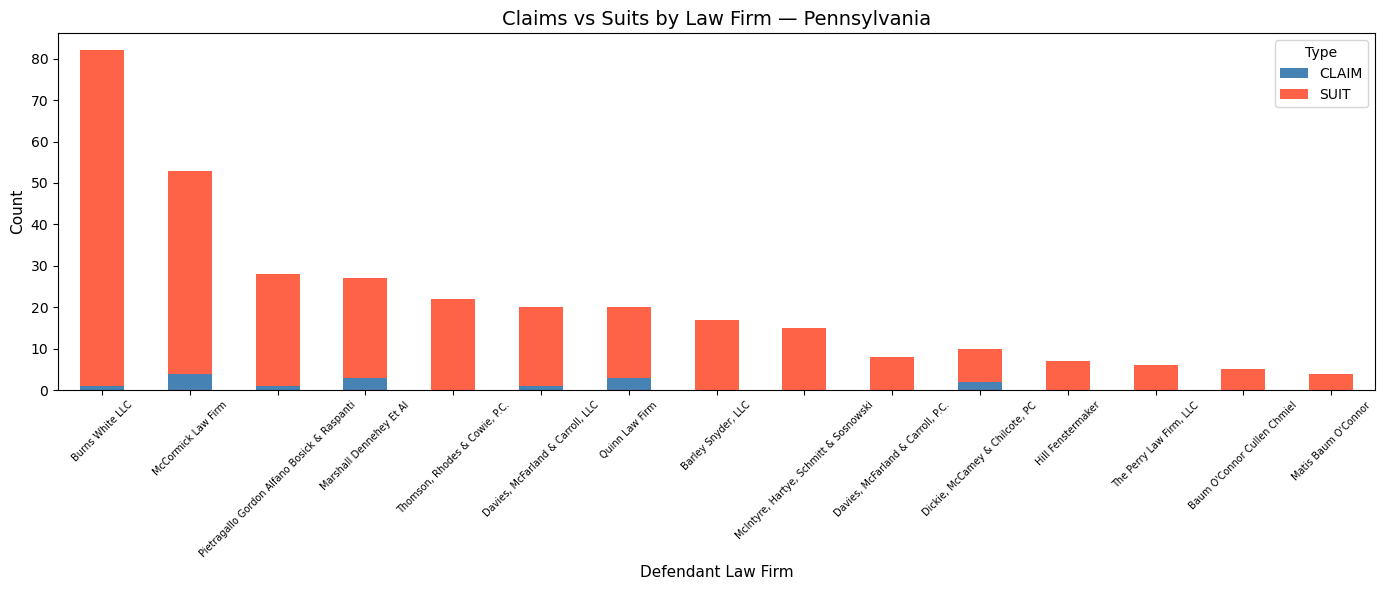

In [13]:
# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, color=['steelblue', 'tomato'])

location_label = f'{selected_county}, {selected_state}' if selected_county else selected_state
ax.set_title(f'Claims vs Suits by Law Firm — {location_label}', fontsize=14)
ax.set_xlabel('Defendant Law Firm', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.legend(title='Type')
plt.tight_layout()
plt.show()

In [15]:
state_summary = (
    df.groupby(['state', 'current_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['CLAIM', 'SUIT'], fill_value=0)
)

print(state_summary)

current_type   CLAIM  SUIT
state                     
Connecticut        0    29
New York           6   763
Pennsylvania      16   840
West Virginia      3    25
